In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
np.random.seed(123)

df = pd.read_csv("data/health_study_dataset.csv")

df_mask = ["age", "weight", "height", "systolic_bp", "cholesterol"]
df[df_mask].mean()

age             49.426250
weight          73.413000
height         171.849250
systolic_bp    149.178625
cholesterol      4.929150
dtype: float64

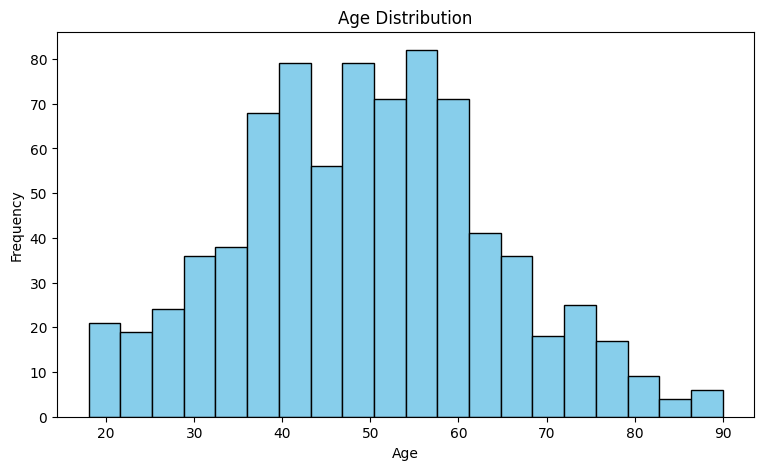

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["age"], bins=20, color="skyblue", edgecolor="black")
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
plt.show()

Shows the distribution of ages

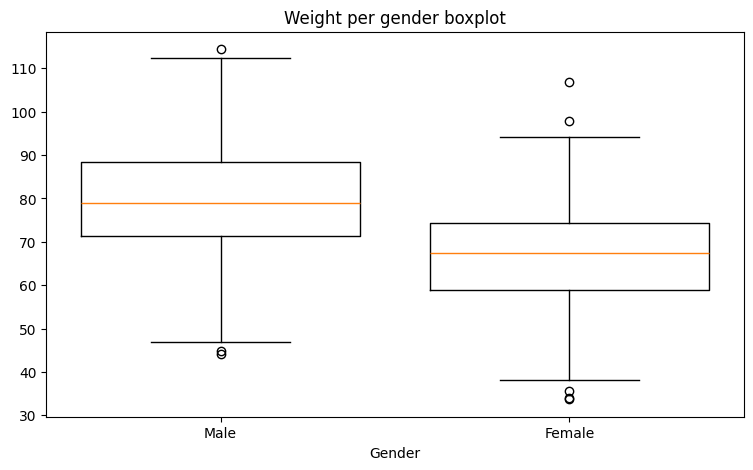

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([df[df["sex"] == "M"]["weight"],
			df[df["sex"] == "F"]["weight"]],
			tick_labels=["Male", "Female"],
			widths=0.8)
ax.set_title("Weight per gender boxplot")
ax.set_xlabel("Gender")
plt.show()

Shows the weight per gender. Dots outside are outliers.

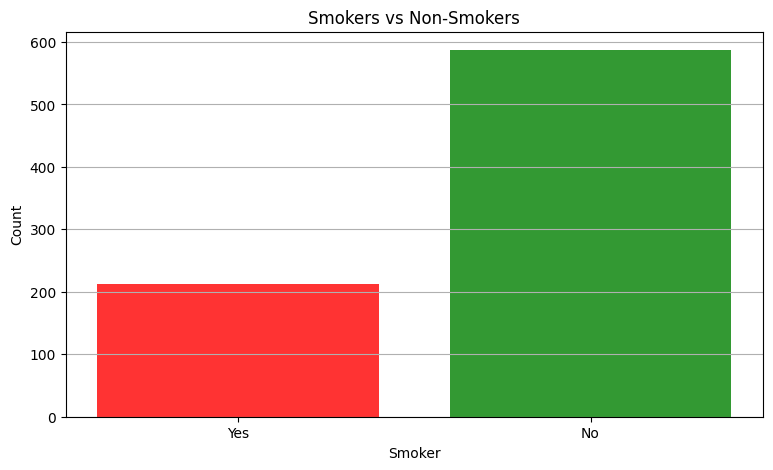

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

x = ["Yes", "No"]
y = [df[df["smoker"] == "Yes"]["smoker"].count(), df[df["smoker"] == "No"]["smoker"].count()]

ax.bar(x, y, color=["red", "green"], alpha=0.8)
ax.set_title("Smokers vs Non-Smokers")
ax.set_xlabel("Smoker")
ax.set_ylabel("Count")
ax.grid(axis="y")
plt.show()

Compares the amount of smokers vs non-smokers.

In [5]:
# Calculating number of sick and healthy individuals and sick rate
actual_sick = df[df["disease"] == 1]["systolic_bp"].count()
actual_healthy = df[df["disease"] == 0]["systolic_bp"].count()
actual_sick_rate = actual_sick / len(df)#df.__len__()
print(f"Healthy: {actual_healthy}\nSick: {actual_sick}\nSick rate: {actual_sick_rate}")

Healthy: 753
Sick: 47
Sick rate: 0.05875


Calculates the true count of sick vs healthy people and the sick rate of those.

In [6]:
# Simulate 1000 people with the same sick rate
n = 1000

sim_df = pd.DataFrame()
sim_df["id"] = range(1, n + 1)
sim_df["age"] = np.random.normal(df["age"].mean(), df["age"].std(), n).round().astype(int)
sim_df["sex"] = np.random.choice(["M", "F"], n)
sim_df["weight"] = np.random.normal(df["weight"].mean(), df["weight"].std(), n).round(1)
sim_df["height"] = np.random.normal(df["height"].mean(), df["height"].std(), n).round(1)
sim_df["systolic_bp"] = np.random.normal(df["systolic_bp"].mean(), df["systolic_bp"].std(), n).round().astype(float)
sim_df["cholesterol"] = np.random.normal(df["cholesterol"].mean(), df["cholesterol"].std(), n).round().astype(float)
sim_df["smoker"] = np.random.choice(["Yes", "No"], n)
sim_df["disease"] = np.random.choice([1, 0], n, p=[actual_sick_rate, 1 - actual_sick_rate])


In [7]:
# Sampling distribution of sickness rate
def sample_mean(_n, _sim_df) -> float:
	"""
	Calculates the sample mean of size _n from the population _pop
	Args:
		_n (int): Sample size
		_pop (array-like): Population
	Returns:
		float: Sample mean
	"""
	return np.mean(np.random.choice(_sim_df, size=_n, replace=False))

# How many sample means to calculate
R = 1000
means_n50 = np.array([sample_mean(50, sim_df["disease"]) for _ in range(R)])
means_n200 = np.array([sample_mean(200, sim_df["disease"]) for _ in range(R)])


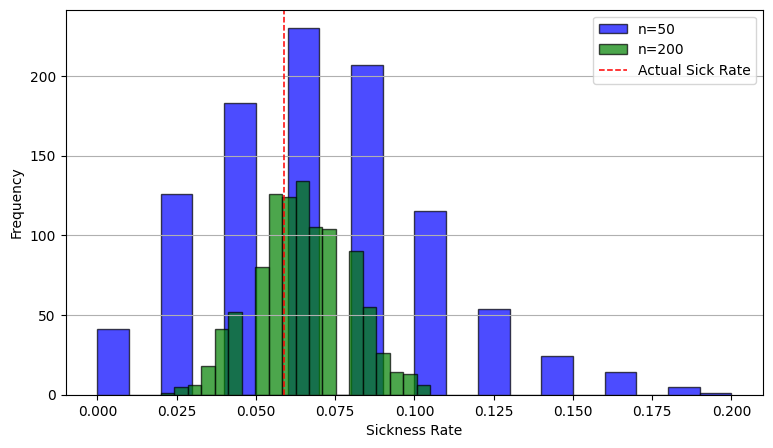

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(means_n50, bins=20, alpha=0.7, label="n=50", color="blue", edgecolor="black")
ax.hist(means_n200, bins=20, alpha=0.7, label="n=200", color="green", edgecolor="black")
ax.set_xlabel("Sickness Rate")
ax.set_ylabel("Frequency")
ax.axvline(actual_sick_rate, color="red", linestyle="dashed", linewidth=1.1, label="Actual Sick Rate")
ax.grid(axis="y")
ax.legend()
plt.show()

Compares the sick rate of a simulated population of 1000 with the true sick rate
We see that the simulated sick rate is shifted to the right of the true sick rate. This is likely due to our small simulated population that give rise to bigger fluctuations. If a larger simulated population size was used the simulated sick rate would get close to the true sick rate. Another likely reason is that a constant random seed is used and the simulated data got "stuck" at that shift. Using a random seed might resolve this.

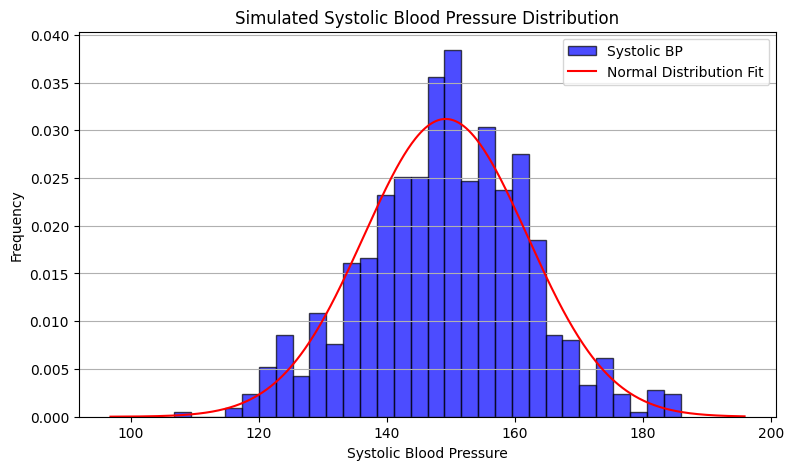

In [ ]:
# Normal PDF function
def normal_pdf(_x, _m, _s):
	"""
	Calculates th y-values for the normal probability density function given x-values, mean and standard deviation.
	Args:
		_x (array-like): x-values
		_m (float): Mean
		_s (float): Standard deviation
	Returns:
		array-like: y-values
	"""
	_x = np.asarray(_x, dtype=float)
	if _s <= 0 or not np.isfinite(_s):
		raise ValueError("Standard deviation must be positive and finite!")
	
	norm = 1.0 / (_s * np.sqrt(2.0 * np.pi))
	z = (_x - _m) / _s
	y = norm * np.exp(-0.5 * z ** 2)
	return y

# Mean, median, std of simulated systolic blood pressure
mean_bp = np.mean(df["systolic_bp"])
median_bp = np.median(df["systolic_bp"])
std_bp = np.std(df["systolic_bp"], ddof=1)

# x and y values for normal pdf plot
x_values = np.linspace(df["systolic_bp"].min() - 10, df["systolic_bp"].max() + 10, 500)
y_values = normal_pdf(x_values, mean_bp, std_bp)

# Create fig and ax
fig, ax = plt.subplots(figsize=(9, 5))

# What to plot
ax.hist(df["systolic_bp"], bins=30, color="blue", alpha=0.7, edgecolor="black", label="Systolic BP", density=True)
ax.plot(x_values, y_values, color="red", label="Normal Distribution Fit")

# Plot settings
ax.set_title("Simulated Systolic Blood Pressure Distribution")
ax.set_xlabel("Systolic Blood Pressure")
ax.set_ylabel("Frequency")
ax.grid(axis="y")
ax.legend()
plt.show()


# Confidence Interval Normal Approximation Method

In [ ]:
# Normal Approximation Method Confidence Interval
def ci_mean_normal(_sample: np.array, _confidence: float=0.95) -> tuple:
	"""
	Calculates the 95% confidence interval for the mean using the normal approximation method.
	Bounds: mean ± 1.96 * (std / sqrt(n))
	Args:
		_x (array-like): Sample data
		_sample_size (int): Size of sample
		_confidence (float): Confidence level
	Returns:
		tuple: Higher bound, lower bound, sample mean, sample std
	"""
	_sample = np.asarray(_sample, dtype=float)
	mean = float(np.mean(_sample))
	std = float(np.std(_sample, ddof=1))
	z_crit = 1.96
	error = z_crit * (std / np.sqrt(len(_sample)))
	return float(mean - error), float(mean + error), float(mean), float(std)

def ci_mean_bootstrap(_sample: np.array, _resample_size: int=5000, _confidence: float=0.95) -> tuple:
	_sample = np.asarray(_sample, dtype=float)
	_sample_size = len(_sample)
	boot_means = np.empty(_resample_size)
	for i in range(_resample_size):
		boot_sample = np.random.choice(_sample, size=_sample_size)
		boot_means[i] = np.mean(boot_sample)

	alpha = (1 - _confidence) / 2.0
	lo, hi = np.percentile(boot_means, [100.0*alpha, 100.0*(1.0 - alpha)])
	return float(lo), float(hi), float(_sample.mean()), float(_sample.std())

# Bootstrap testing
print(f"Normal confidence interval:    {ci_mean_normal(df["systolic_bp"])}")
print(f"Bootstrap confidence intreval: {ci_mean_bootstrap(df["systolic_bp"])}")

"""
# Run 1000 randomized samples of size 50 of the main sample of 800 and check that roughly 95% of the samples cover the actual_mean_sys_bp
actual_mean_sys_bp = float(df["systolic_bp"].mean())
sample_size = 50
runs = 1000
count = [0, 0]

# Rows for the dataframe of samples
rows = []

for i in range(runs):
	sample = np.random.choice(df["systolic_bp"], size=sample_size, replace=True)
	sample_lo, sample_hi, sample_mean, sample_std = ci_mean_normal(sample, sample_size)

	rows.append({
		"id": i,
		"high": sample_hi,
		"low": sample_lo,
		"mean": sample_mean,
		"std": sample_std,
		"in_interval": int(sample_lo < actual_mean_sys_bp < sample_hi)
	})

# Create dataframe of the samples
samples_df = pd.DataFrame(rows)
display(samples_df)

in_interval_rate = 1.0 - (samples_df[samples_df["in_interval"] == 0]["in_interval"].count() / samples_df[samples_df["in_interval"] == 1]["in_interval"].count())
print(f"{in_interval_rate * 100.0:.2f}% of the {runs} simulated samples lie within the 95% confidence interval.")

fig, ax = plt.subplots(figsize=(9, 5))
nr_to_plot = 100
ax.errorbar(samples_df["id"][:nr_to_plot],
			samples_df["mean"][:nr_to_plot],
			yerr=[samples_df["mean"][:nr_to_plot] - samples_df["low"][:nr_to_plot], samples_df["high"][:nr_to_plot] - samples_df["mean"][:nr_to_plot]],
			fmt="o",
			capsize=0.2,
			lw=0.3,
			markersize=1)
ax.axhline(y=df["systolic_bp"].mean(), color=("green"), linestyle="--", label="Actual systolic bp mean")
ax.set_xlabel("Simulation number (sample size 50)")
ax.set_ylabel("Systolic bp")
ax.legend()
ax.grid(axis="y")
plt.plot()"""


Normal confidence interval:    (148.29209036025347, 150.06515963974655, 149.178625, 12.793360316766597)
Bootstrap confidence intreval: (148.289471875, 150.047759375, 149.178625, 12.785361966302519)


'\n# Run 1000 randomized samples of size 50 of the main sample of 800 and check that roughly 95% of the samples cover the actual_mean_sys_bp\nactual_mean_sys_bp = float(df["systolic_bp"].mean())\nsample_size = 50\nruns = 1000\ncount = [0, 0]\n\n# Rows for the dataframe of samples\nrows = []\n\nfor i in range(runs):\n\tsample = np.random.choice(df["systolic_bp"], size=sample_size, replace=True)\n\tsample_lo, sample_hi, sample_mean, sample_std = ci_mean_normal(sample, sample_size)\n\n\trows.append({\n\t\t"id": i,\n\t\t"high": sample_hi,\n\t\t"low": sample_lo,\n\t\t"mean": sample_mean,\n\t\t"std": sample_std,\n\t\t"in_interval": int(sample_lo < actual_mean_sys_bp < sample_hi)\n\t})\n\n# Create dataframe of the samples\nsamples_df = pd.DataFrame(rows)\ndisplay(samples_df)\n\nin_interval_rate = 1.0 - (samples_df[samples_df["in_interval"] == 0]["in_interval"].count() / samples_df[samples_df["in_interval"] == 1]["in_interval"].count())\nprint(f"{in_interval_rate * 100.0:.2f}% of the {runs} si

## Graph analysis
- The above graph shows the error bars for the first 100 simulated bp with the actual mean bp.
- Roughly 5 of the error bars should not intersect the reference mean bp

Calculates the confidence interval 1000 times for a sample of 50 and checks the percentage of times it lies within the 95% confidence interval

# Hypothesis Testing
- **T-test**
- **Bootstrap**

- **Claim:** Smokers have higher mean bp than non-smokers - Alt hyp h1, µ > average bp.
- **Opp:** Smokers have less than or equal mean bp than non-smokers - Null hyp h0,  µ = average bp.
- Can only test h0, if h1 is the claim and h0 proved wrong, the claim is correct.

In [ ]:
from scipy import stats

smoker_mean_bp = df[df["smoker"] == "Yes"]["systolic_bp"].mean()
non_smoker_mean_bp = df[df["smoker"] == "No"]["systolic_bp"].mean()
mean_obs_diff = abs(smoker_mean_bp - non_smoker_mean_bp)

print(f"Smokers mean bp: {smoker_mean_bp}\nNon smokers mean bp: {non_smoker_mean_bp}\nObserved bp difference: {mean_obs_diff}")
# Claim: Smokers have a higher mean bp than non smokers       -> µ_s > µ_ns -> µ_ns > µ_ns -> h1
# Opp: Smokers have a lower or equal mean bp than non smokers -> µ_s ≤ µ_ns -> µ_s  = µ_ns -> h0 -> reject h0 to prove h1
# Goal: Attempt to prove the claim (h1) true by rejecting h0

smokers = df.loc[df.smoker == "Yes", "systolic_bp"].values
non_smokers = df.loc[df.smoker == "No", "systolic_bp"].values

# Standard T-test (Assumers same variance)
t_stat, p_val = stats.ttest_ind(smokers, non_smokers, equal_var=True, alternative="greater")

# Welch t-test (Assumers not same variance, makes more sense in practice)
t_stat_w, p_val_w = stats.ttest_ind(smokers, non_smokers, equal_var=False, alternative="greater")

print(f"Standard t-test: t={t_stat:.3f}, p={p_val:.4f}")
print(f"Welch    t-test: t={t_stat_w:.3f}, p={p_val_w:.4f}")

if p_val < 0.05:
	print(f"Null hypothesis can be rejected.")
else:
	print(f"Failed to reject the Null hypothesis.")

Smokers mean bp: 149.524882629108
Non smokers mean bp: 149.05298126064736
Observed bp difference: 0.47190136846063524
Standard t-test: t=0.461, p=0.3225
Welch    t-test: t=0.450, p=0.3264
Failed to reject the Null hypothesis.


In [ ]:
# Bootstrap
n_boot = 10_000

smoker_mean_bp = smokers.mean()
non_smoker_mean_bp = non_smokers.mean()
mean_obs_diff = abs(smoker_mean_bp - non_smoker_mean_bp)

boot_diffs = np.empty(n_boot)
for i in range(n_boot):
	sm_start = np.random.choice(smokers, size=len(smokers), replace=True)
	ns_start = np.random.choice(non_smokers, size=len(non_smokers), replace=True)
	boot_diffs[i] = sm_start.mean() - ns_start.mean()

p_boot = np.mean(np.abs(boot_diffs) >= abs(mean_obs_diff)) / 2.0
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(mean_obs_diff, p_boot, (ci_low, ci_high))

0.47190136846063524 0.34285 (np.float64(-1.5381318433028375), np.float64(2.5354543073317775))
